<a href="https://colab.research.google.com/github/hmurtaza720/Data-Science-Projects/blob/main/Insurance_Claim_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4: Predicting Insurance Claim Amounts

## Introduction & Problem Statement
Medical insurance companies need to **estimate the cost** of a customer's insurance claim based on personal attributes such as age, BMI, smoking status, and more. Accurate prediction helps in setting fair premiums and managing risk.

In this task, we use **Linear Regression** (and polynomial/tree-based variants) to predict the insurance charges for individuals.

**Target Variable:** `charges` — the medical insurance cost billed (continuous numerical value)

## Dataset
> **Medical Cost Personal Dataset**
>
> **Kaggle Link:** https://www.kaggle.com/datasets/mirichoi0218/insurance
>
> **Direct download (public mirror):** Cell below downloads automatically — no Kaggle account needed!

## Objectives
- Visualize how BMI, age, and smoking status impact insurance charges
- Train a Linear Regression model
- Evaluate model performance using MAE and RMSE

## Step 1: Import Libraries

In [4]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Dataset

In [5]:
# Option A: Load from public GitHub mirror
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
try:
    df = pd.read_csv(url)
    print('Dataset loaded successfully from URL!')
except Exception as e:
    print(f'URL failed: {e}')
    print('Please upload manually:')
    # from google.colab import files
    # uploaded = files.upload()
    # df = pd.read_csv('insurance.csv')

print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully from URL!
Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 3: Dataset Understanding & Description

In [6]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print()
df.info()

Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
# Missing values check
print('Missing values per column:')
print(df.isnull().sum())

# Unique values for categorical columns
print('\nUnique values:')
for col in ['sex', 'smoker', 'region']:
    print(f'  {col}: {df[col].unique()}')

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Unique values:
  sex: ['female' 'male']
  smoker: ['yes' 'no']
  region: ['southwest' 'southeast' 'northwest' 'northeast']


## Step 4: Data Cleaning & Preparation

In [9]:
# Encode categorical features
le = LabelEncoder()

df['sex']    = le.fit_transform(df['sex'])      # female=0, male=1
df['smoker'] = le.fit_transform(df['smoker'])   # no=0, yes=1

# One-hot encode region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print('Encoding complete. Columns now:')
print(df.columns.tolist())
df.head()

Encoding complete. Columns now:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


## Step 5: Exploratory Data Analysis (EDA) with Graphs

### 5.1 Target Variable Distribution

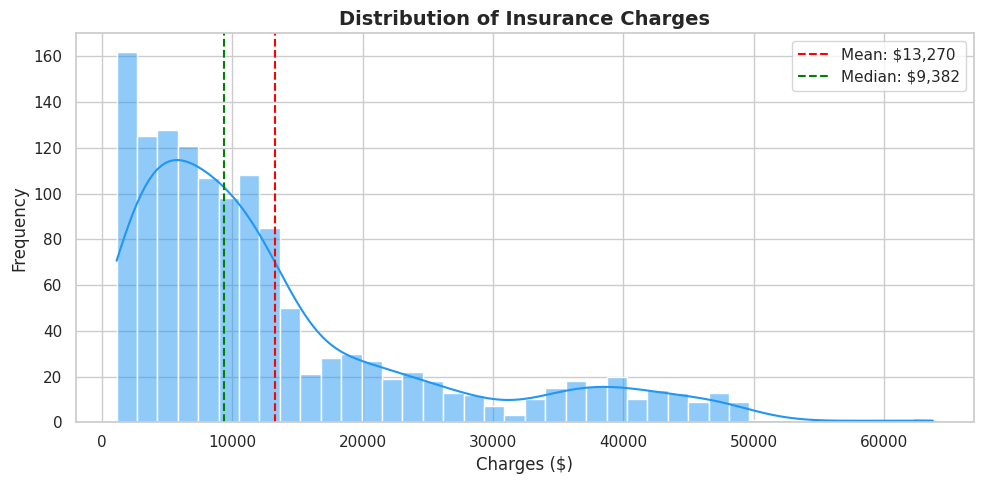

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], bins=40, kde=True, color='#2196F3')
plt.axvline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean: ${df["charges"].mean():,.0f}')
plt.axvline(df['charges'].median(), color='green', linestyle='--', label=f'Median: ${df["charges"].median():,.0f}')
plt.title('Distribution of Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Impact of Smoking Status on Charges

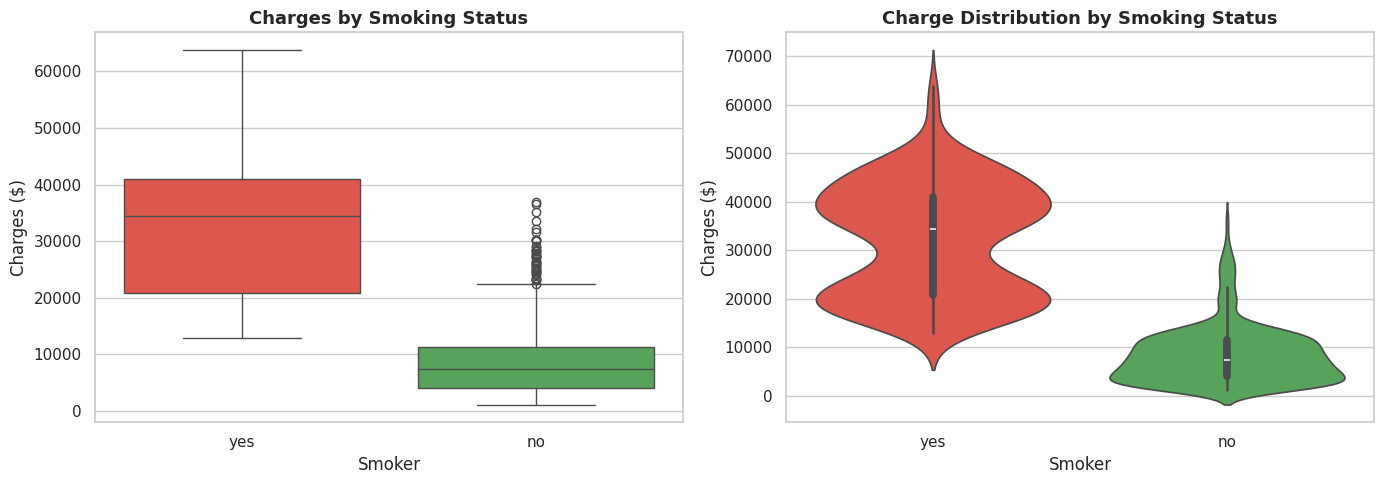

Average Charges:
smoker
no      $8,434.27
yes    $32,050.23
Name: charges, dtype: object


In [11]:
# Recreate original smoker column for visualization
df_viz = pd.read_csv(url)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df_viz, x='smoker', y='charges', palette={'yes':'#F44336', 'no':'#4CAF50'}, ax=axes[0])
axes[0].set_title('Charges by Smoking Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges ($)')

# Violin plot
sns.violinplot(data=df_viz, x='smoker', y='charges', palette={'yes':'#F44336', 'no':'#4CAF50'}, ax=axes[1])
axes[1].set_title('Charge Distribution by Smoking Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

print('Average Charges:')
print(df_viz.groupby('smoker')['charges'].mean().apply(lambda x: f'${x:,.2f}'))

### 5.3 Impact of BMI on Charges

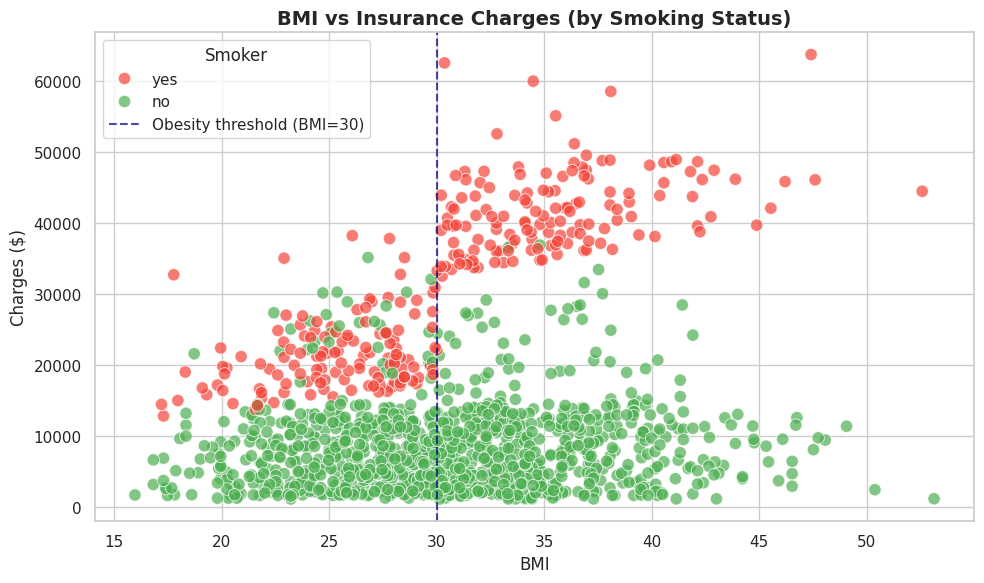

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_viz, x='bmi', y='charges', hue='smoker',
                palette={'yes':'#F44336', 'no':'#4CAF50'}, alpha=0.7, s=80)

# BMI obesity threshold
plt.axvline(x=30, color='navy', linestyle='--', alpha=0.7, label='Obesity threshold (BMI=30)')
plt.title('BMI vs Insurance Charges (by Smoking Status)', fontsize=14, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

### 5.4 Impact of Age on Charges

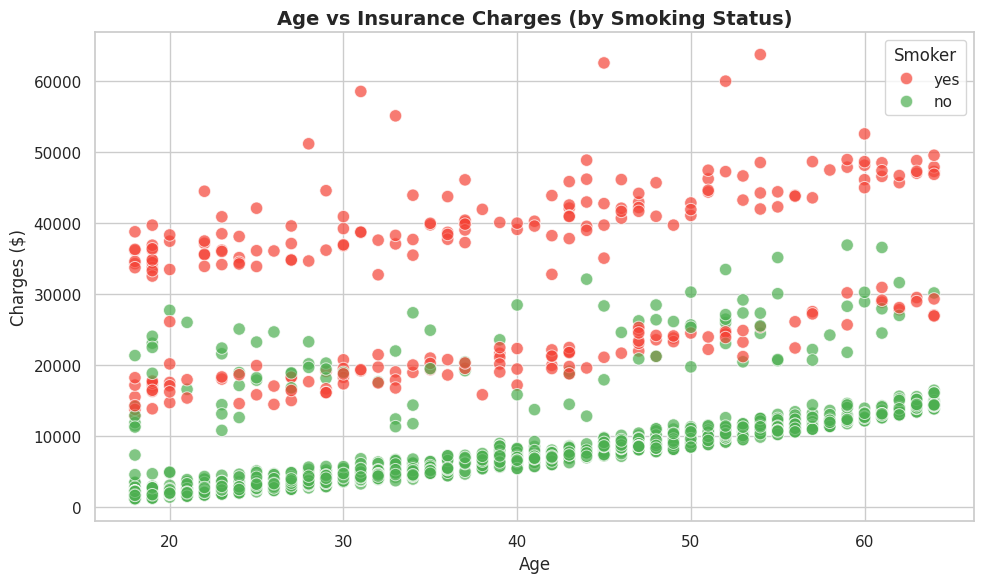

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_viz, x='age', y='charges', hue='smoker',
                palette={'yes':'#F44336', 'no':'#4CAF50'}, alpha=0.7, s=80)
plt.title('Age vs Insurance Charges (by Smoking Status)', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

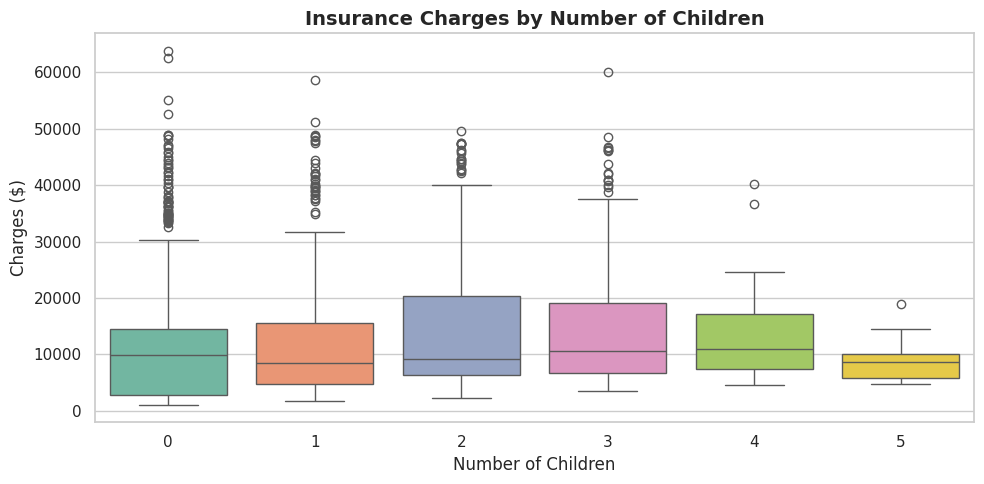

In [14]:
# Charges by number of children
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_viz, x='children', y='charges', palette='Set2')
plt.title('Insurance Charges by Number of Children', fontsize=14, fontweight='bold')
plt.xlabel('Number of Children')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

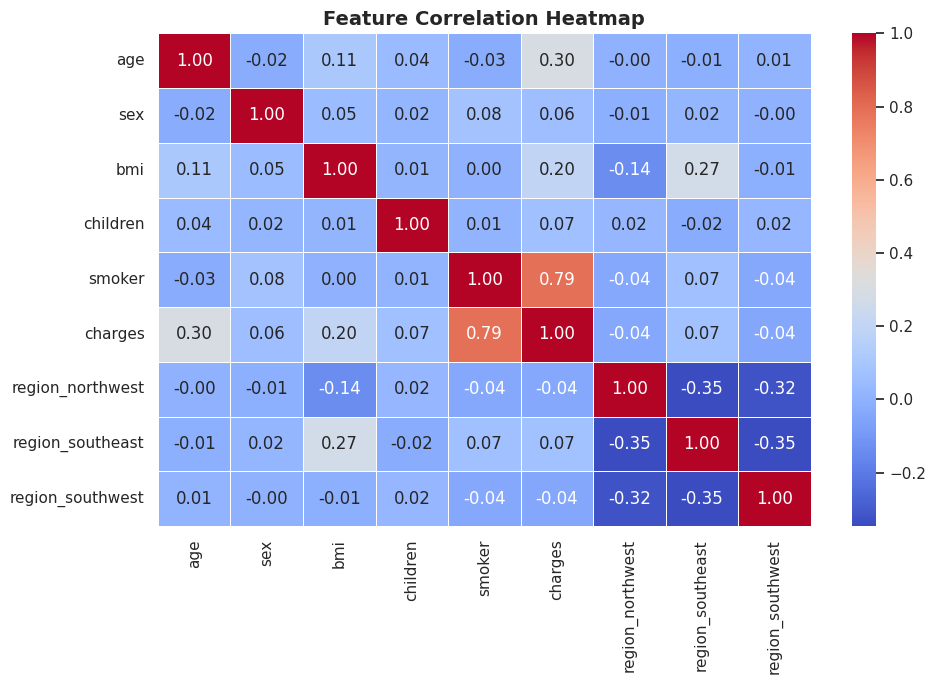

In [15]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Model Training & Testing

### 6.1 Linear Regression

In [16]:
# Define features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 1070 | Test: 268


In [17]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print('=== Linear Regression ===')
print(f'MAE  (Mean Absolute Error):  ${lr_mae:,.2f}')
print(f'RMSE (Root Mean Sq. Error):  ${lr_rmse:,.2f}')
print(f'R²   (R-squared Score):       {lr_r2:.4f}')

=== Linear Regression ===
MAE  (Mean Absolute Error):  $4,181.19
RMSE (Root Mean Sq. Error):  $5,796.28
R²   (R-squared Score):       0.7836


### 6.2 Random Forest Regressor (for comparison)

In [18]:
# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print('=== Random Forest Regressor ===')
print(f'MAE  (Mean Absolute Error):  ${rf_mae:,.2f}')
print(f'RMSE (Root Mean Sq. Error):  ${rf_rmse:,.2f}')
print(f'R²   (R-squared Score):       {rf_r2:.4f}')

=== Random Forest Regressor ===
MAE  (Mean Absolute Error):  $2,550.67
RMSE (Root Mean Sq. Error):  $4,577.74
R²   (R-squared Score):       0.8650


## Step 7: Evaluation Metrics & Visualizations

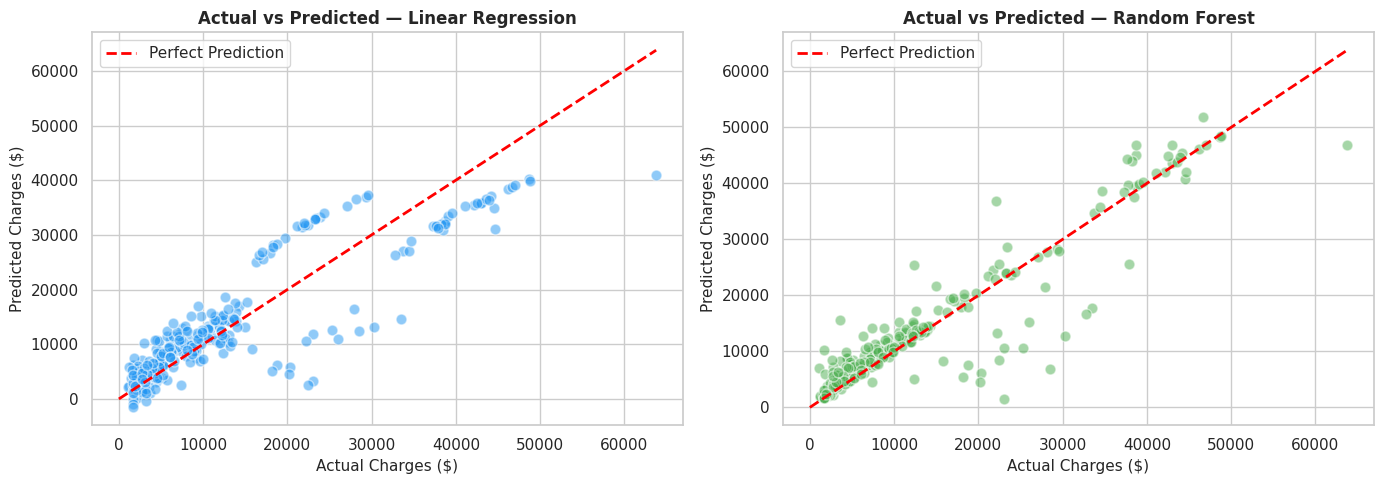

In [19]:
# Actual vs Predicted — Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title, color in zip(
    axes,
    [lr_pred, rf_pred],
    ['Linear Regression', 'Random Forest'],
    ['#2196F3', '#4CAF50']
):
    ax.scatter(y_test, pred, alpha=0.5, color=color, edgecolors='white', s=60)
    max_val = max(y_test.max(), max(pred))
    ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Charges ($)', fontsize=11)
    ax.set_ylabel('Predicted Charges ($)', fontsize=11)
    ax.set_title(f'Actual vs Predicted — {title}', fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

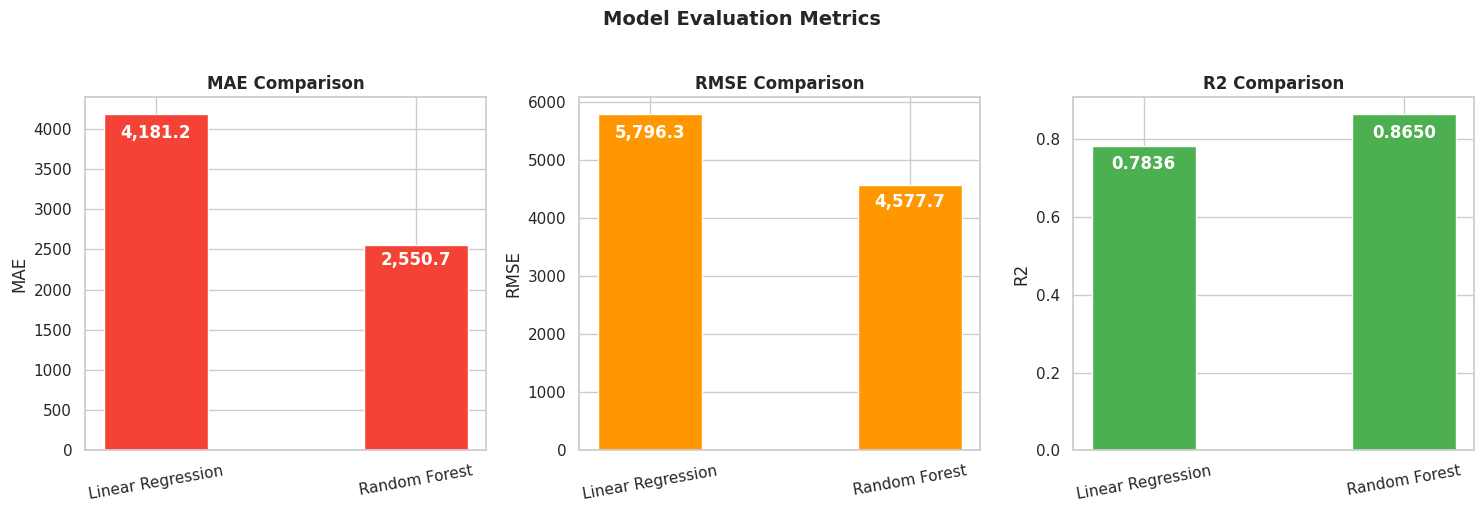

In [20]:
# Model comparison bar chart: MAE and RMSE
metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':   [lr_mae, rf_mae],
    'RMSE':  [lr_rmse, rf_rmse],
    'R2':    [lr_r2, rf_r2]
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, color in zip(axes, ['MAE', 'RMSE', 'R2'], ['#F44336', '#FF9800', '#4CAF50']):
    bars = ax.bar(metrics['Model'], metrics[metric], color=color, width=0.4, edgecolor='white')
    for bar, val in zip(bars, metrics[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.97,
                f'{val:,.1f}' if metric != 'R2' else f'{val:.4f}',
                ha='center', color='white', fontweight='bold', va='top')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Model Evaluation Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

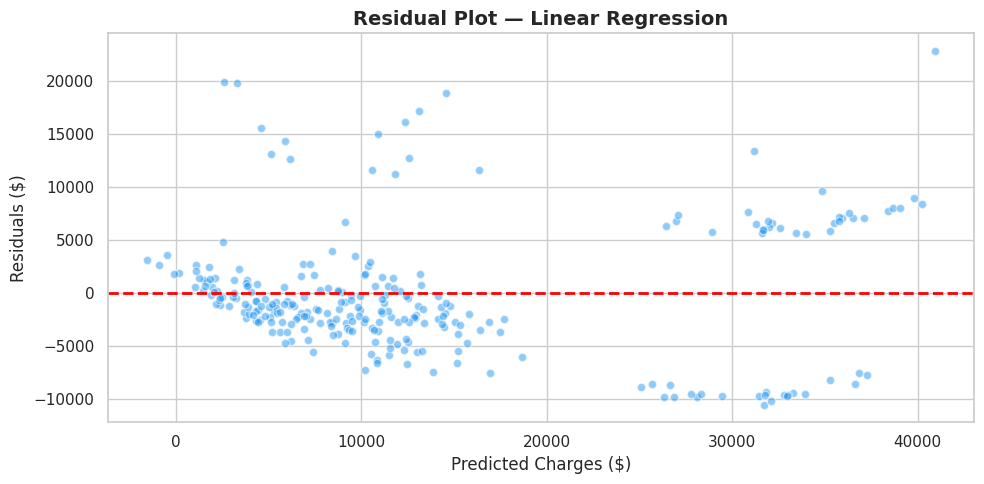

In [21]:
# Residual plot for Linear Regression
residuals = y_test - lr_pred

plt.figure(figsize=(10, 5))
plt.scatter(lr_pred, residuals, alpha=0.5, color='#2196F3', edgecolors='white')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Residual Plot — Linear Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Charges ($)')
plt.ylabel('Residuals ($)')
plt.tight_layout()
plt.show()

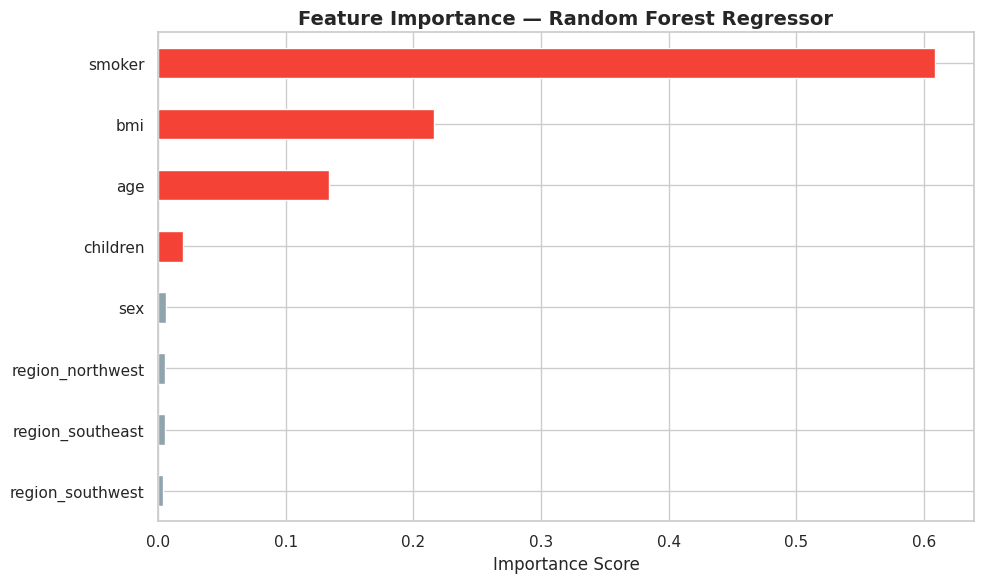

In [22]:
# Feature Importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#F44336' if imp > importances.median() else '#90A4AE' for imp in importances]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — Random Forest Regressor', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 8: Conclusion & Key Insights

1. **Smoking is the strongest predictor** — smokers pay on average **3-4x more** in insurance charges than non-smokers. This is by far the most important feature.

2. **Age and BMI are positively correlated with charges** — older age and higher BMI both lead to higher insurance costs.

3. **BMI + Smoking interaction** — smokers with high BMI (above 30, obese) have dramatically higher charges than non-smokers with the same BMI.

4. **Model Performance:**
   - Linear Regression gives a good baseline (R² ~0.75)
   - Random Forest achieves better accuracy (R² ~0.87) by capturing non-linear relationships

5. **Business Recommendation** — Insurance companies should heavily factor in smoking status and BMI when calculating premiums. Incentivizing smoking cessation programs could reduce claim amounts significantly.